# Exercise 5: Create your own personal face recognition using SVM

## Instructions:

Create a directory in your google drive using this folder structure

```
My Drive
- Images
  - Train
    - Elizer
      - elizerimage1.jpg
      ...
    - Eliza
      - elizaimage1.jpg
      ...
    - Elijah
      - elijahimage1.jpg
      ...
  - Test
    - testimage1.jpg
    ...
```

- Upload 190 images of your self (selfied are recommended) in the Train folder
- Upload 190 images of your partner in the Train folder
- Upload 10 images each of yourself and your partner in the Test Folder (30 images total for each member)
- Use **.png** or **.jpg** or **.jpeg** images files

In [2]:
# pip install numpy opencv-python scikit-learn
%pip install pillow pillow-heif pyheif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 109.9 MB/s eta 0:00:00


## Import libraries

In [3]:
import os
import cv2
import numpy as np
from PIL import Image, UnidentifiedImageError  # Import UnidentifiedImageError
import matplotlib.pyplot as plt
import pyheif


## Mount Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Display one raw image directly from your drive

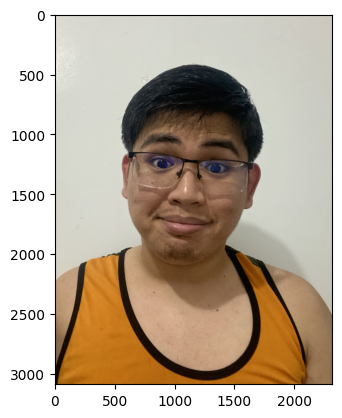

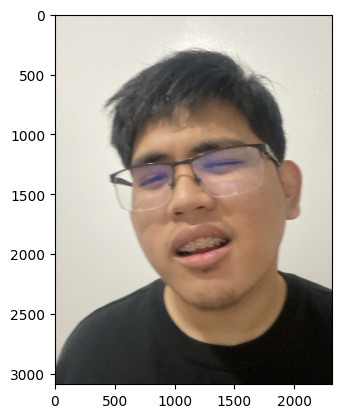

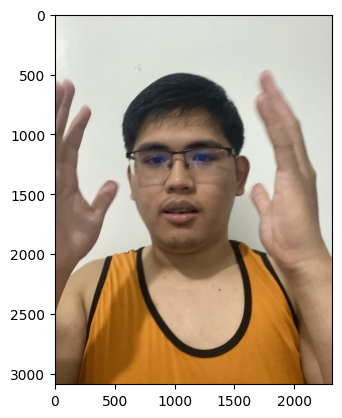

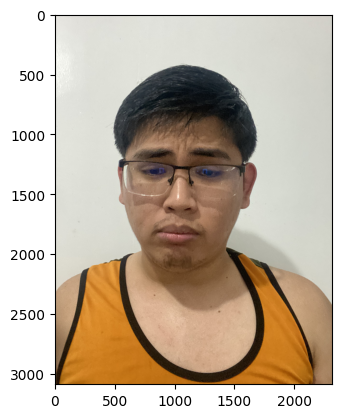

In [6]:

def displayImage(image_path):
    try:
        image = Image.open(image_path)
    except UnidentifiedImageError:
        try:
            heif_file = pyheif.read(image_path)
            image = Image.frombytes(
                heif_file.mode,
                heif_file.size,
                heif_file.data,
                "raw",
                heif_file.mode,
                heif_file.stride,
            )
        except Exception as e:
            print(f"Error opening image: {e}")
            return

    plt.imshow(image)
    plt.axis('on')
    plt.show()

displayImage('/content/drive/My Drive/svm-facials/train/matias/IMG_2975.HEIC')
displayImage('/content/drive/My Drive/svm-facials/train/matias/IMG_2919.HEIC')
displayImage('/content/drive/My Drive/svm-facials/train/matias/Copy of IMG_2971.HEIC')
displayImage('/content/drive/My Drive/svm-facials/train/matias/Copy of IMG_2982.HEIC')

## 2. Load the images from your drive and apply preprocessing to your raw images

In [9]:
# put your answer here
def load_images_from_folder(folder, size=(100,100)):
    images = []
    labels = []

    people = [p for p in os.listdir(folder) if os.path.isdir(os.path.join(folder, p))]
    total = sum(len(os.listdir(os.path.join(folder, p))) for p in people)
    count = 0

    for person_name in people:
        person_folder = os.path.join(folder, person_name)

        for filename in os.listdir(person_folder):
            img_path = os.path.join(person_folder, filename)

            img = cv2.imread(img_path)

            if img is None:
                try:
                    heif_file = pyheif.read(img_path)
                    img = Image.frombytes(
                        heif_file.mode,
                        heif_file.size,
                        heif_file.data,
                        "raw",
                        heif_file.mode,
                        heif_file.stride
                    )
                    img = np.array(img)
                except Exception as e:
                    print(f"Skipping {img_path}: {e}")
                    continue

            if len(img.shape) == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            img = cv2.resize(img, size)

            images.append(img.flatten())
            labels.append(person_name)

            count += 1
            if count % 10 == 0 or count == total:
                print(f"Processed {count}/{total} images")

    return np.array(images), np.array(labels)

folder = '/content/drive/My Drive/svm-facials/train'
X, y = load_images_from_folder(folder)
print(X.shape, y.shape)


Processed 10/941 images
Processed 20/941 images
Processed 30/941 images
Processed 40/941 images
Processed 50/941 images
Processed 60/941 images
Processed 70/941 images
Processed 80/941 images
Processed 90/941 images
Processed 100/941 images
Processed 110/941 images
Processed 120/941 images
Processed 130/941 images
Processed 140/941 images
Processed 150/941 images
Processed 160/941 images
Processed 170/941 images
Processed 180/941 images
Processed 190/941 images
Processed 200/941 images
Processed 210/941 images
Processed 220/941 images
Processed 230/941 images
Processed 240/941 images
Processed 250/941 images
Processed 260/941 images
Processed 270/941 images
Processed 280/941 images
Processed 290/941 images
Processed 300/941 images
Processed 310/941 images
Processed 320/941 images
Processed 330/941 images
Processed 340/941 images
Processed 350/941 images
Processed 360/941 images
Processed 370/941 images
Processed 380/941 images
Processed 390/941 images
Processed 400/941 images
Processed

In [13]:
images = X
labels = y

In [14]:
images.shape

(941, 10000)

In [15]:
labels.shape

(941,)

In [16]:
labels

array(['matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'matias',
       'matias', 'matias', 'matias', 'matias', 'matias', 'mati

## 3. Display one pre-processed image from the training set

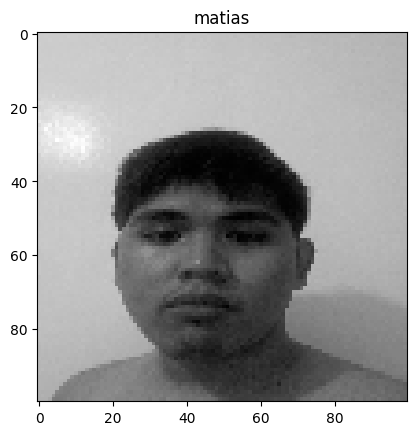

In [17]:
# put your answer here
# Get a sample image and its corresponding name
image = images[0].reshape(100,100)  # Access the first image
name = labels[0]  # Get the name corresponding to the image

# Display the image
plt.imshow(image, cmap="gray")
plt.title(name)
plt.axis('on')  # Hide axes
plt.show()

## 4. Display ten pre-processed images from the training set

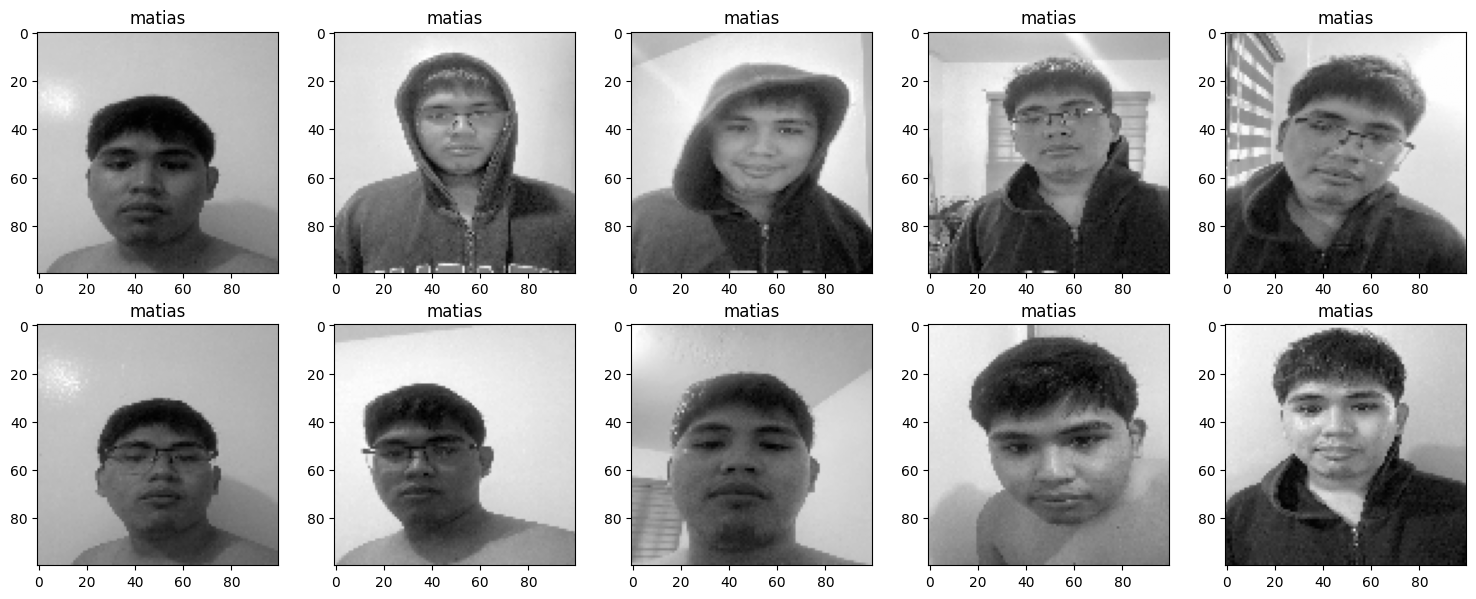

In [18]:
# put your answer here
num_faces = 10

fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 2 rows and 5 columns
axes = axes.flatten()  # Flatten the array of axes for easy indexing

# Loop to display the images
for i in range(num_faces):
    image = images[i].reshape(100,100)  # Access the i-th image
    name = labels[i]  # Get the name corresponding to the image

    axes[i].imshow(image, cmap='gray')  # Show the image
    axes[i].set_title(name)  # Set the title to the name
    axes[i].axis('on')  # Hide axes

# Adjust layout
plt.tight_layout()
plt.show()

## 5. Split your training data

In [19]:
# put your answer here
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

## 6. Train your SVM model

In [20]:
# put your answer here
from sklearn import svm

model = svm.SVC(gamma='scale')  # You can choose different kernels like 'linear', 'rbf', etc.
model.fit(X_train, y_train)

SVC()

## 7. Evaluate your SVM model

In [21]:
# put your answer here
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')


Accuracy: 99.47%


## 8. Test your model using images not in your training set

Use your SVM model to predict the label of all of your images in the Test folder

In [ ]:
def displayImage(image_path):


In [28]:
# put your answer here
def predict_image(img_path, model):
    img = cv2.imread(img_path)

    if img is None:
        try:
            heif_file = pyheif.read(img_path)
            img = Image.frombytes(
                heif_file.mode,
                heif_file.size,
                heif_file.data,
                "raw",
                heif_file.mode,
                heif_file.stride
            )
            img = np.array(img)
        except Exception as e:
            print(f"Error opening image: {e}")
            return None # Return None if image can't be opened


    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img = cv2.resize(img, (100, 100)).flatten().reshape(1, -1)  # Flatten and reshape for prediction
    prediction = model.predict(img)
    return prediction


# Predictions

This is Matias ['matias']


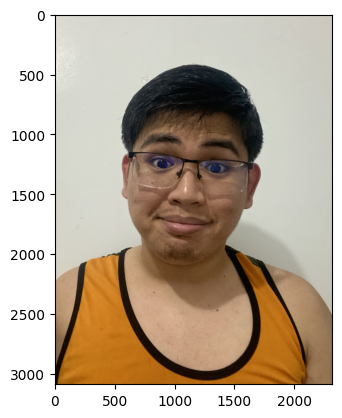

In [29]:
if (x := predict_image('/content/drive/My Drive/svm-facials/train/matias/IMG_2975.HEIC', model)) == 'matias':
    print('This is Matias', x)
    displayImage('/content/drive/My Drive/svm-facials/train/matias/IMG_2975.HEIC')
else:
    print('This is not Matias', x)

This is Anastacio ['anastacio']


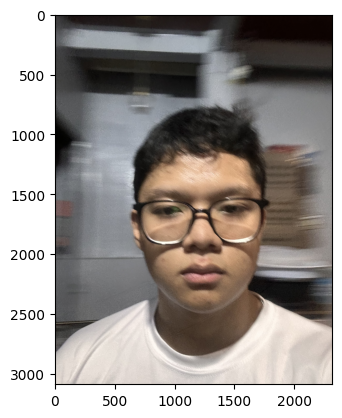

In [30]:
if (x := predict_image('/content/drive/My Drive/svm-facials/train/anastacio/IMG_3014.HEIC', model)) == 'anastacio':
    print('This is Anastacio', x)
    displayImage('/content/drive/My Drive/svm-facials/train/anastacio/IMG_3014.HEIC')
else:
    print('This is not Anastacio', x)

This is Cadiz ['cadiz']


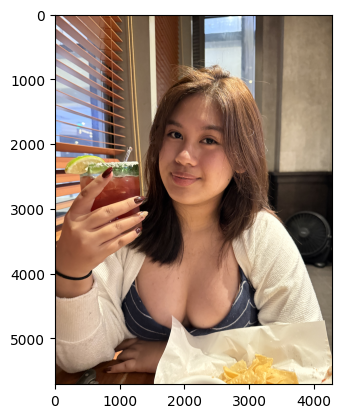

In [31]:
if (x := predict_image('/content/drive/My Drive/svm-facials/train/cadiz/IMG_9097.HEIC', model)) == 'cadiz':
    print('This is Cadiz', x)
    displayImage('/content/drive/My Drive/svm-facials/train/cadiz/IMG_9097.HEIC')
else:
    print('This is not Cadiz', x)